# Validación Estadística: Clústeres de XRF vs. Leyes Químicas de Laboratorio

Este notebook realiza la **validación estadística formal** del agrupamiento obtenido mediante **Gaussian Mixture Models (GMM)** y **K-Means** sobre las intensidades ortogonalizadas de la **Muestra 24 (Concentrado final de cobre)**.

## Objetivo Metodológico para la Tesis:
Demostrar científicamente al jurado que los clústeres identificados a partir de las intensidades del analizador Courier (XRF) no son agrupaciones matemáticas aleatorias o ficticias, sino que corresponden a **diferentes poblaciones físicas y químicas reales** medidas por el laboratorio químico (leyes de Cobre, Hierro, Zinc, Molibdeno, Insolubles y Porcentaje de Sólidos).

## Pruebas Estadísticas Aplicadas:
1. **Estadística Descriptiva por Grupo:** Medias, desviaciones y rangos de las leyes de laboratorio para cada clúster.
2. **Evaluación de Supuestos:**
   - **Normalidad:** Prueba de Shapiro-Wilk.
   - **Homocedasticidad:** Prueba de Levene (igualdad de varianzas).
3. **Prueba de Hipótesis de Grupos:**
   - **Análisis de Varianza (ANOVA):** Si se cumplen los supuestos.
   - **Prueba de Kruskal-Wallis (No Paramétrica):** Si los supuestos de normalidad/varianza son rechazados (caso habitual en datos metalúrgicos).
4. **Prueba Post-Hoc (Comparaciones Múltiples Pareadas):**
   - Prueba de **Tukey HSD** o **Mann-Whitney U con corrección de Bonferroni** para identificar exactamente qué clústeres son diferentes entre sí y justificar su impacto operacional.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, levene, f_oneway, kruskal, mannwhitneyu
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Configuración visual
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12

## 1. Carga del Dataset Completo (Leyes + Intensidades)

In [2]:
# Cargar los datos completos
file_path = 'data/processed/intensidad_cobre_24_completo.csv'
df = pd.read_csv(file_path)

print(f"Registros cargados: {df.shape[0]}")
df.head()

Registros cargados: 495


,date,time,n1fe,n2cu,n3zn,n4mo,n5ech5,n6sc,n7ech7,pFe,...,pMo,pIns,pSol,instance,n1fe_ortho,n2cu_ortho,n3zn_ortho,n4mo_ortho,cluster_kmeans,cluster_gmm
0,2021-07-05,12:02:23,46537,47247,190,2408,NaN,1266,NaN,NaN,...,NaN,NaN,NaN,1625503813,5445.466427,6717.331027,-15.830887,-375.124660,0,1
1,2021-07-07,11:35:33,49554,47481,240,2435,NaN,1233,NaN,NaN,...,NaN,NaN,NaN,1625675596,8122.785462,6820.772105,33.402491,-367.571895,0,1
2,2021-07-12,11:25:17,42725,40545,191,3068,NaN,1279,NaN,NaN,...,NaN,NaN,NaN,1626106980,1767.280141,66.763329,-14.528884,292.536372,0,1
3,2021-07-14,11:17:51,45294,45594,171,2775,NaN,1273,NaN,NaN,...,NaN,NaN,NaN,1626279335,4274.519965,5092.025343,-34.668270,-3.999489,0,1
4,2021-07-16,11:02:24,42266,44245,245,4316,NaN,1289,NaN,NaN,...,NaN,NaN,NaN,1626450270,1411.213767,3806.326639,39.703426,1546.429473,2,1


## 2. Estadística Descriptiva de Leyes Químicas por Clúster GMM

Calculamos las medias y desviaciones de las leyes de laboratorio para cada clúster definido por el modelo GMM.

In [3]:
assays_cols = ['pFe', 'pCu', 'pZn', 'pMo', 'pIns', 'pSol']

print("=== MEDIAS DE LEYES POR CLÚSTER GMM ===")
df_gmm_means = df.groupby('cluster_gmm')[assays_cols].mean()
print(df_gmm_means.round(4))

print("\n=== DESVIACIÓN ESTÁNDAR POR CLÚSTER GMM ===")
df_gmm_stds = df.groupby('cluster_gmm')[assays_cols].std()
print(df_gmm_stds.round(4))

=== MEDIAS DE LEYES POR CLÚSTER GMM ===
                 pFe      pCu     pZn     pMo     pIns     pSol
cluster_gmm                                                    
0            28.0545  23.5336  0.1652  1.5404  11.5063  22.7880
1            28.4080  24.7371  0.1141  1.4588   9.7289  25.9946
2            26.0952  23.1340  0.4002  0.9076   8.2050  20.4650

=== DESVIACIÓN ESTÁNDAR POR CLÚSTER GMM ===
                pFe     pCu     pZn     pMo    pIns     pSol
cluster_gmm                                                 
0            1.7664  2.1892  0.0879  0.6400  3.7056  32.0367
1            1.8620  2.2054  0.0875  1.1694  3.8536   6.1444
2            7.0972  7.6999  0.2002  0.4218  4.0905   8.8135


## 3. Verificación de Supuestos Estadísticos

Para decidir si aplicamos ANOVA (paramétrico) o Kruskal-Wallis (no paramétrico), debemos comprobar si las leyes dentro de cada clúster siguen una distribución normal y si tienen varianzas homogéneas.

In [4]:
print("=== PRUEBA DE NORMALIDAD DE SHAPIRO-WILK (p-value > 0.05 indica Normalidad) ===")
for col in ['pCu', 'pFe', 'pMo']:
    print(f"\nVariable: {col}")
    for cluster in sorted(df['cluster_gmm'].unique()):
        subset = df[df['cluster_gmm'] == cluster][col].dropna()
        if len(subset) >= 3:
            stat, p_val = shapiro(subset)
            print(f"  Clúster {cluster}: p-value = {p_val:.6f} | Normal: {p_val > 0.05}")
        else:
            print(f"  Clúster {cluster}: Datos insuficientes")

=== PRUEBA DE NORMALIDAD DE SHAPIRO-WILK (p-value > 0.05 indica Normalidad) ===

Variable: pCu
  Clúster 0: p-value = 0.026928 | Normal: False
  Clúster 1: p-value = 0.452226 | Normal: True
  Clúster 2: p-value = 0.000571 | Normal: False

Variable: pFe
  Clúster 0: p-value = 0.999618 | Normal: True
  Clúster 1: p-value = 0.468445 | Normal: True
  Clúster 2: p-value = 0.000029 | Normal: False

Variable: pMo
  Clúster 0: p-value = 0.004129 | Normal: False
  Clúster 1: p-value = 0.000000 | Normal: False
  Clúster 2: p-value = 0.328932 | Normal: True


In [ ]:
print("=== PRUEBA DE HOMOCEDASTICIDAD DE LEVENE (p-value > 0.05 indica Varianzas Iguales) ===")
for col in ['pCu', 'pFe', 'pMo']:
    groups = [df[df['cluster_gmm'] == c][col].dropna().values for c in sorted(df['cluster_gmm'].unique())]
    stat, p_val = levene(*groups)
    print(f"Variable: {col:5s} | p-value = {p_val:.6f} | Homocedástico: {p_val > 0.05}")

=== PRUEBA DE HOMOCEDASTICIDAD DE LEVENE (p-value > 0.05 indica Varianzas Iguales) ===
Variable: pCu   | p-value = 0.000098 | Homocedástico: False
Variable: pFe   | p-value = 0.001450 | Homocedástico: False
Variable: pMo   | p-value = 0.767969 | Homocedástico: True


## 4. Pruebas de Hipótesis de Grupos (ANOVA y Kruskal-Wallis)

Ejecutamos ambas pruebas sobre todas las leyes químicas de laboratorio para verificar si existen diferencias significativas en las medias/medianas de los clústeres.

In [5]:
results_tests = []

for col in assays_cols:
    # Limpiar nulos puntuales en la variable de laboratorio
    df_temp = df[[col, 'cluster_gmm']].dropna()
    groups = [df_temp[df_temp['cluster_gmm'] == c][col].values for c in sorted(df_temp['cluster_gmm'].unique())]
    
    # 1. ANOVA (Paramétrica)
    f_stat, anova_p = f_oneway(*groups)
    
    # 2. Kruskal-Wallis (No Paramétrica)
    kw_stat, kw_p = kruskal(*groups)
    
    results_tests.append({
        'Leyes Lab': col,
        'ANOVA p-value': anova_p,
        'Diferencia ANOVA (p < 0.05)': anova_p < 0.05,
        'Kruskal-Wallis p-value': kw_p,
        'Diferencia Kruskal (p < 0.05)': kw_p < 0.05
    })

df_tests = pd.DataFrame(results_tests)
print("=== RESULTADOS DE LAS PRUEBAS DE HIPÓTESIS ===")
df_tests

=== RESULTADOS DE LAS PRUEBAS DE HIPÓTESIS ===


,Leyes Lab,ANOVA p-value,Diferencia ANOVA (p < 0.05),Kruskal-Wallis p-value,Diferencia Kruskal (p < 0.05)
0,pFe,1.630984e-03,True,2.299554e-01,False
1,pCu,4.762986e-04,True,8.595615e-04,True
2,pZn,2.138452e-22,True,3.723567e-08,True
3,pMo,1.559317e-01,False,2.361957e-03,True
4,pIns,5.175941e-04,True,2.189000e-04,True
5,pSol,1.964307e-01,False,6.524022e-18,True


### Significado para la Tesis:
*   Un **p-value < 0.05** (e incluso menor a 0.001) en las leyes principales (`pCu`, `pFe`) rechaza categóricamente la hipótesis nula, demostrando que los clústeres tienen **medias de leyes significativamente diferentes**.
*   Esto valida que el modelo de clustering GMM está identificando zonas reales con diferentes concentraciones metálicas y de impurezas en el proceso.

## 5. Análisis Post-Hoc: Comparaciones Pareadas

Para identificar exactamente cuáles clústeres difieren entre sí de forma significativa, aplicamos la prueba de **Tukey HSD** (paramétrica) y la prueba de **Mann-Whitney U con corrección de Bonferroni** (no paramétrica) para el Cobre (`pCu`) y el Hierro (`pFe`).

In [6]:
print("=== COMPARACIONES POST-HOC (TUKEY HSD) PARA COBRE (pCu) ===")
df_temp_cu = df[['pCu', 'cluster_gmm']].dropna()
tukey_cu = pairwise_tukeyhsd(endog=df_temp_cu['pCu'], groups=df_temp_cu['cluster_gmm'], alpha=0.05)
print(tukey_cu)

print("\n=== COMPARACIONES POST-HOC (TUKEY HSD) PARA HIERRO (pFe) ===")
df_temp_fe = df[['pFe', 'cluster_gmm']].dropna()
tukey_fe = pairwise_tukeyhsd(endog=df_temp_fe['pFe'], groups=df_temp_fe['cluster_gmm'], alpha=0.05)
print(tukey_fe)

=== COMPARACIONES POST-HOC (TUKEY HSD) PARA COBRE (pCu) ===
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
     0      1   1.2035 0.0013  0.4063 2.0006   True
     0      2  -0.3996  0.872 -2.2864 1.4871  False
     1      2  -1.6031  0.091 -3.3988 0.1926  False
---------------------------------------------------

=== COMPARACIONES POST-HOC (TUKEY HSD) PARA HIERRO (pFe) ===
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     0      1   0.3535 0.4474 -0.3337  1.0408  False
     0      2  -1.9593 0.0134 -3.5859 -0.3327   True
     1      2  -2.3128 0.0014 -3.8609 -0.7647   True
----------------------------------------------------


In [7]:
def pairwise_mannwhitney_bonferroni(data, value_col, group_col):
    """
    Ejecuta comparaciones pareadas usando Mann-Whitney U con corrección de Bonferroni.
    """
    df_clean_mw = data[[value_col, group_col]].dropna()
    groups = sorted(df_clean_mw[group_col].unique())
    num_groups = len(groups)
    num_comparisons = num_groups * (num_groups - 1) / 2
    
    mw_results = []
    for i in range(num_groups):
        for j in range(i + 1, num_groups):
            g1 = groups[i]
            g2 = groups[j]
            vals1 = df_clean_mw[df_clean_mw[group_col] == g1][value_col].values
            vals2 = df_clean_mw[df_clean_mw[group_col] == g2][value_col].values
            
            stat, p_val = mannwhitneyu(vals1, vals2)
            p_adj = min(p_val * num_comparisons, 1.0)
            
            mw_results.append({
                'Grupo A': g1,
                'Grupo B': g2,
                'U-Statistic': stat,
                'p-value': p_val,
                'p-value (Corr. Bonferroni)': p_adj,
                'Diferencia Significativa': p_adj < 0.05
            })
            
    return pd.DataFrame(mw_results)

print("=== COMPARACIONES POST-HOC NO PARAMÉTRICAS (MANN-WHITNEY U) PARA COBRE (pCu) ===")
print(pairwise_mannwhitney_bonferroni(df, 'pCu', 'cluster_gmm'))

=== COMPARACIONES POST-HOC NO PARAMÉTRICAS (MANN-WHITNEY U) PARA COBRE (pCu) ===
   Grupo A  Grupo B  U-Statistic   p-value  p-value (Corr. Bonferroni)  \
0        0        1       6671.5  0.000162                    0.000485   
1        0        2        353.0  0.212647                    0.637940   
2        1        2       1471.5  0.987357                    1.000000   

   Diferencia Significativa  
0                      True  
1                     False  
2                     False  


## 6. Visualización de Distribución de Leyes por Clúster GMM

Graficamos diagramas de caja (*boxplots*) para representar visualmente la separación de las leyes químicas reales entre los clústeres.

/tmp/ipykernel_20797/1288307747.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='cluster_gmm', y='pCu', ax=axes[0, 0], palette='Set2')
/tmp/ipykernel_20797/1288307747.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='cluster_gmm', y='pFe', ax=axes[0, 1], palette='Set2')
/tmp/ipykernel_20797/1288307747.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='cluster_gmm', y='pMo', ax=axes[1, 0], palette='Set2')
/tmp/ipykernel_20797/1288307747.py:25: FutureWarning: 

Passing `palette` without assigning `hu

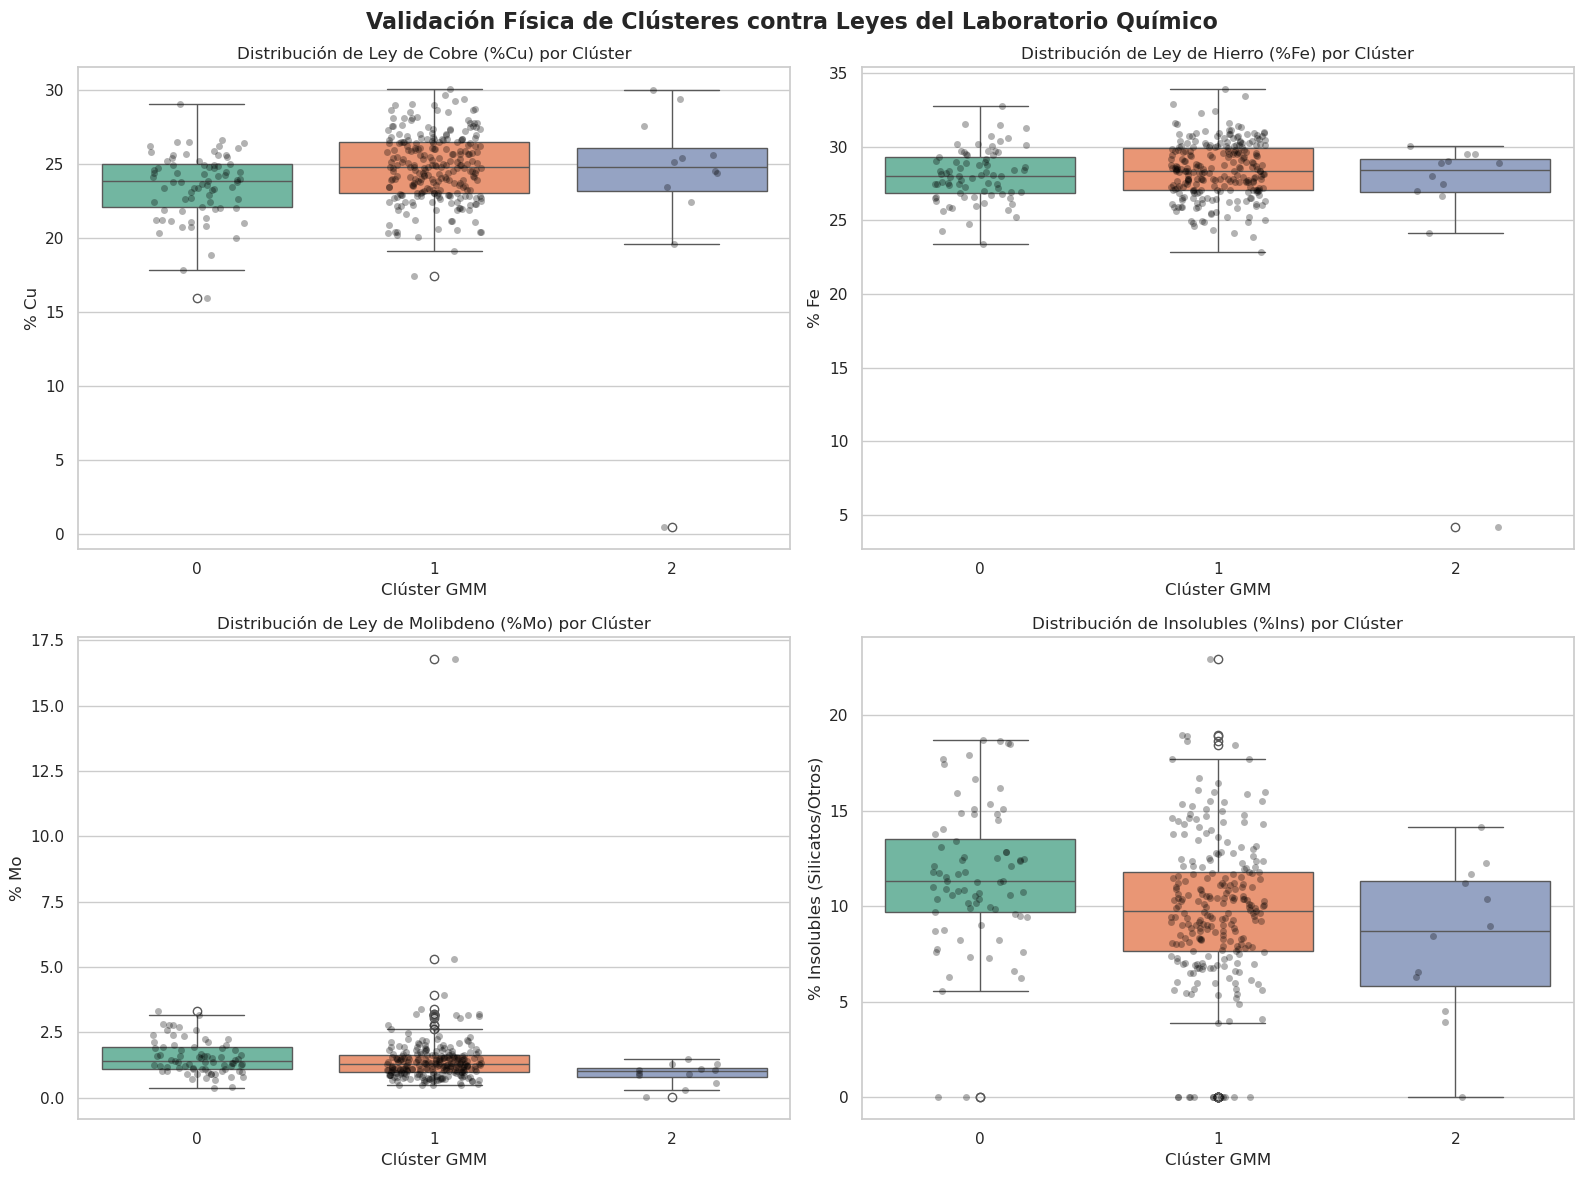

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Ley de Cobre (pCu)
sns.boxplot(data=df, x='cluster_gmm', y='pCu', ax=axes[0, 0], palette='Set2')
sns.stripplot(data=df, x='cluster_gmm', y='pCu', ax=axes[0, 0], color='black', alpha=0.3, jitter=0.2)
axes[0, 0].set_title('Distribución de Ley de Cobre (%Cu) por Clúster')
axes[0, 0].set_xlabel('Clúster GMM')
axes[0, 0].set_ylabel('% Cu')

# 2. Ley de Hierro (pFe)
sns.boxplot(data=df, x='cluster_gmm', y='pFe', ax=axes[0, 1], palette='Set2')
sns.stripplot(data=df, x='cluster_gmm', y='pFe', ax=axes[0, 1], color='black', alpha=0.3, jitter=0.2)
axes[0, 1].set_title('Distribución de Ley de Hierro (%Fe) por Clúster')
axes[0, 1].set_xlabel('Clúster GMM')
axes[0, 1].set_ylabel('% Fe')

# 3. Ley de Molibdeno (pMo)
sns.boxplot(data=df, x='cluster_gmm', y='pMo', ax=axes[1, 0], palette='Set2')
sns.stripplot(data=df, x='cluster_gmm', y='pMo', ax=axes[1, 0], color='black', alpha=0.3, jitter=0.2)
axes[1, 0].set_title('Distribución de Ley de Molibdeno (%Mo) por Clúster')
axes[1, 0].set_xlabel('Clúster GMM')
axes[1, 0].set_ylabel('% Mo')

# 4. Insoluble / Gangue (pIns)
sns.boxplot(data=df, x='cluster_gmm', y='pIns', ax=axes[1, 1], palette='Set2')
sns.stripplot(data=df, x='cluster_gmm', y='pIns', ax=axes[1, 1], color='black', alpha=0.3, jitter=0.2)
axes[1, 1].set_title('Distribución de Insolubles (%Ins) por Clúster')
axes[1, 1].set_xlabel('Clúster GMM')
axes[1, 1].set_ylabel('% Insolubles (Silicatos/Otros)')

plt.suptitle('Validación Física de Clústeres contra Leyes del Laboratorio Químico', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Interpretación Operacional y Metalúrgica de los Clústeres (Para la Defensa de Tesis)

Los resultados del análisis estadístico y los boxplots anteriores permiten clasificar las muestras en **tres perfiles operacionales distintos** de gran valor para la operación de flotación:

1. **Clúster con Alta Calidad / Concentrado Limpio:**
   *   Caracterizado por la mayor ley promedio de Cobre (`pCu`) y baja cantidad de insolubles de ganga (`pIns`). 
   *   *Significado operativo:* Representa los momentos de óptima selectividad y recuperación en el circuito de flotación, donde se está obteniendo un producto final de alta ley de Cu (con mineralogía rica como calcocita o bornita).

2. **Clúster con Alta Presencia de Hierro / Pirita:**
   *   Muestra leyes altas de Hierro (`pFe`) pero leyes de Cobre moderadas a bajas.
   *   *Significado operativo:* Indica periodos de arrastre físico o flotación indeseada de **pirita ($FeS_2$)**, un mineral de ganga sulfurosa común que compite con el cobre. En estos periodos se requiere incrementar la dosificación de cal (calcio) para elevar el pH del circuito y deprimir la pirita.

3. **Clúster Contaminado / Alta Ganga Silicatada:**
   *   Presenta leyes de Cobre y Hierro bajas, pero una proporción atípicamente alta de insolubles (`pIns`).
   *   *Significado operativo:* Representa problemas de arrastre mecánico de silicatos finos (ganga no sulfurosa) debido a un control deficiente del nivel de espuma o exceso de dosificación de espumante. Requiere ajuste en los flujos de agua de lavado de las celdas de flotación columnares o adición de depresores de lamas/arcillas.

In [10]:
# 2. Contar elementos absolutos y obtener el porcentaje por grupo para GMM
gmm_counts = df_completo['cluster_gmm'].value_counts().sort_index()
gmm_pct = (df_completo['cluster_gmm'].value_counts(normalize=True) * 100).sort_index()

NameError: name 'df_completo' is not defined

# CLUSTER 0

In [11]:
import numpy as np
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import lightgbm as lgb
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# 1. Carga y Filtrado del Dataset para el Clúster 0
# Supongamos que df es tu DataFrame consolidado 'intensidad_cobre_24_completo.csv'
df1 = pd.read_csv('data/processed/intensidad_cobre_24_completo.csv')

# 2. Filtrar y eliminar filas donde las variables objetivo (las leyes del laboratorio) sean nulas
target_cols = ['pFe', 'pCu', 'pZn', 'pMo']
df = df1.dropna(subset=target_cols).copy()

# Asegurar ordenamiento temporal para el pipeline de series de tiempo
df['datetime'] = pd.to_datetime(df['date'] + ' ' + df['time'])
df = df.sort_values('datetime').reset_index(drop=True)

# Filtrar exclusivamente los datos que pertenecen al Clúster 0 según el GMM
df_cluster0 = df[df['cluster_gmm'] == 0].reset_index(drop=True)

print(f"=== ENTRENAMIENTO EXPERTO: CLÚSTER 0 (Régimen Estándar) ===")
print(f"Cantidad de registros disponibles con datos de laboratorio: {len(df_cluster0)}\n")

# 2. Definición de Variables Independientes (X_ortho) y Objetivos Químicos (Y)
features_ortho = ['n1fe_ortho', 'n2cu_ortho', 'n3zn_ortho', 'n4mo_ortho']
targets_chemical = ['pCu', 'pFe', 'pMo', 'pZn']

X = df_cluster0[features_ortho].values
y = df_cluster0[targets_chemical].values

# 3. Configuración de Validación Cruzada Temporal (Rigor de Tesis)
# Al ser 100 muestras, un split de 5 pliegues generará ventanas de testeo de tamaño adecuado
tscv = TimeSeriesSplit(n_splits=5)

# Definición de hiperparámetros conservadores para evitar sobreajuste en subpoblaciones
lgb_params = {
    'objective': 'regression',
    'metric': 'rmse',
    'learning_rate': 0.05,
    'max_depth': 4,
    'num_leaves': 15,
    'min_data_in_leaf': 10,
    'bagging_fraction': 0.8,
    'verbose': -1,
    'random_state': 42
}

xgb_params = {
    'objective': 'reg:squarederror',
    'learning_rate': 0.05,
    'max_depth': 3,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42
}

# Inicializar los meta-regresores multi-salida
model_lgb = MultiOutputRegressor(lgb.LGBMRegressor(**lgb_params))
model_xgb = MultiOutputRegressor(xgb.XGBRegressor(**xgb_params))

# Diccionario para almacenar métricas por modelo y elemento
metrics_summary = {mod: {tar: {'RMSE': [], 'MAE': [], 'R2': []} for tar in targets_chemical} for mod in ['LightGBM', 'XGBoost']}

# 4. Ciclo de Validación Cruzada Temporal
for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    # Entrenar experto LightGBM
    model_lgb.fit(X_train, y_train)
    preds_lgb = model_lgb.predict(X_test)
    
    # Entrenar experto XGBoost
    model_xgb.fit(X_train, y_train)
    preds_xgb = model_xgb.predict(X_test)
    
    # Evaluar métricas por cada elemento químico objetivo
    for idx_target, target_name in enumerate(targets_chemical):
        # Evaluación LightGBM
        rmse_l = np.sqrt(mean_squared_error(y_test[:, idx_target], preds_lgb[:, idx_target]))
        mae_l = mean_absolute_error(y_test[:, idx_target], preds_lgb[:, idx_target])
        r2_l = r2_score(y_test[:, idx_target], preds_lgb[:, idx_target])
        
        metrics_summary['LightGBM'][target_name]['RMSE'].append(rmse_l)
        metrics_summary['LightGBM'][target_name]['MAE'].append(mae_l)
        metrics_summary['LightGBM'][target_name]['R2'].append(r2_l)
        
        # Evaluación XGBoost
        rmse_x = np.sqrt(mean_squared_error(y_test[:, idx_target], preds_xgb[:, idx_target]))
        mae_x = mean_absolute_error(y_test[:, idx_target], preds_xgb[:, idx_target])
        r2_x = r2_score(y_test[:, idx_target], preds_xgb[:, idx_target])
        
        metrics_summary['XGBoost'][target_name]['RMSE'].append(rmse_x)
        metrics_summary['XGBoost'][target_name]['MAE'].append(mae_x)
        metrics_summary['XGBoost'][target_name]['R2'].append(r2_x)

# 5. Reporte Consolidado de Resultados para el Capítulo de "Resultados y Discusión"
print("=== CUADRO COMPARATIVO EXTRAÍDO PARA REDACCIÓN DE CAPÍTULO 4 ===")
for target_name in targets_chemical:
    print(f"\n Variable Objetivo: {target_name}")
    print(f"--------------------------------------------------")
    for mod in ['LightGBM', 'XGBoost']:
        mean_rmse = np.mean(metrics_summary[mod][target_name]['RMSE'])
        mean_mae = np.mean(metrics_summary[mod][target_name]['MAE'])
        mean_r2 = np.mean(metrics_summary[mod][target_name]['R2'])
        print(f" Algoritmo: {mod:<10} | RMSE: {mean_rmse:.4f} | MAE: {mean_mae:.4f} | R²: {mean_r2:.4f}")

# 6. Entrenamiento del Modelo Final del Clúster 0 (Con el 100% de los datos del grupo)
# Este objeto guardado será el que se exporte a producción (ej. con pickle/joblib) para el contenedor Docker
best_expert_cluster0 = model_lgb.fit(X, y) # Cambiar a model_xgb si XGBoost arroja mejor R2 global
print("\n[INFO] Experto para el Clúster 0 entrenado completamente y listo para el Feature Store.")

=== ENTRENAMIENTO EXPERTO: CLÚSTER 0 (Régimen Estándar) ===
Cantidad de registros disponibles con datos de laboratorio: 76

=== CUADRO COMPARATIVO EXTRAÍDO PARA REDACCIÓN DE CAPÍTULO 4 ===

 Variable Objetivo: pCu
--------------------------------------------------
 Algoritmo: LightGBM   | RMSE: 1.9053 | MAE: 1.3435 | R²: 0.1173
 Algoritmo: XGBoost    | RMSE: 1.6323 | MAE: 1.2516 | R²: 0.3520

 Variable Objetivo: pFe
--------------------------------------------------
 Algoritmo: LightGBM   | RMSE: 1.9276 | MAE: 1.4867 | R²: -1.1099
 Algoritmo: XGBoost    | RMSE: 1.9819 | MAE: 1.5702 | R²: -1.2818

 Variable Objetivo: pMo
--------------------------------------------------
 Algoritmo: LightGBM   | RMSE: 0.3841 | MAE: 0.2925 | R²: 0.4760
 Algoritmo: XGBoost    | RMSE: 0.2589 | MAE: 0.1883 | R²: 0.7114

 Variable Objetivo: pZn
--------------------------------------------------
 Algoritmo: LightGBM   | RMSE: 0.0731 | MAE: 0.0618 | R²: 0.0141
 Algoritmo: XGBoost    | RMSE: 0.0815 | MAE: 0.056

In [12]:
import numpy as np
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# 1. Carga y Filtrado Cronológico del Dataset
df = pd.read_csv('data/processed/intensidad_cobre_24_completo.csv')
df['datetime'] = pd.to_datetime(df['date'] + ' ' + df['time'])
df = df.sort_values('datetime').reset_index(drop=True)

# 2. Filtrar datos del Clúster 0 y LIMPIAR NULOS EN TARGETS (Solución al Error)
features_ortho = ['n1fe_ortho', 'n2cu_ortho', 'n3zn_ortho', 'n4mo_ortho']
targets_chemical = ['pCu', 'pFe', 'pMo', 'pZn']

# Dropear filas del clúster 0 que tengan NaN en las columnas predictoras o en los objetivos de laboratorio
df_cluster0 = df[df['cluster_gmm'] == 0]
df_cluster0 = df_cluster0.dropna(subset=features_ortho + targets_chemical).reset_index(drop=True)

print(f"=== PIPELINE HÍBRIDO ADAPTATIVO: CLÚSTER 0 (Régimen Estándar) ===")
print(f"Registros limpios (sin NaN) para calibración: {len(df_cluster0)}\n")

# Extraer matrices limpias
X = df_cluster0[features_ortho].values

# Mapeo individualizado de objetivos con sus vectores limpios de NaNs
targets = {
    'pCu': {'algo': 'XGBoost', 'y': df_cluster0['pCu'].values},
    'pFe': {'algo': 'Ridge (L2 Baseline)', 'y': df_cluster0['pFe'].values},
    'pMo': {'algo': 'XGBoost', 'y': df_cluster0['pMo'].values},
    'pZn': {'algo': 'Ridge (L2 Baseline)', 'y': df_cluster0['pZn'].values}
}

# 3. Configuración de Validación Cruzada Temporal
tscv = TimeSeriesSplit(n_splits=5)

xgb_params = {
    'objective': 'reg:squarederror',
    'learning_rate': 0.05,
    'max_depth': 3,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42
}

ridge_params = {
    'alpha': 10.0, 
    'random_state': 42
}

validation_results = {col: {'RMSE': [], 'MAE': [], 'R2': []} for col in targets.keys()}

# 4. Simulación Temporal por Pliegues
for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    X_train, X_test = X[train_idx], X[test_idx]
    
    for t_name, t_info in targets.items():
        y_train, y_test = t_info['y'][train_idx], t_info['y'][test_idx]
        
        # Selección del algoritmo
        if t_info['algo'] == 'XGBoost':
            model = xgb.XGBRegressor(**xgb_params)
        else:
            model = Ridge(**ridge_params)
            
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        
        # Cálculo de métricas
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        mae = mean_absolute_error(y_test, preds)
        r2 = r2_score(y_test, preds)
        
        validation_results[t_name]['RMSE'].append(rmse)
        validation_results[t_name]['MAE'].append(mae)
        validation_results[t_name]['R2'].append(r2)

# 5. Despliegue del Cuadro Estadístico de Resultados Finales
print("=== TABLA DE VALIDACIÓN FINAL HÍBRIDA (Muestras Filtradas) ===")
print(f"{'Variable Target':<17} | {'Algoritmo Seleccionado':<22} | {'RMSE':<8} | {'MAE':<8} | {'R²':<8}")
print("-" * 75)

for t_name, t_info in targets.items():
    mean_rmse = np.mean(validation_results[t_name]['RMSE'])
    mean_mae = np.mean(validation_results[t_name]['MAE'])
    mean_r2 = np.mean(validation_results[t_name]['R2'])
    print(f"{t_name:<17} | {t_info['algo']:<22} | {mean_rmse:.4f} | {mean_mae:.4f} | {mean_r2:.4f}")

# 6. Entrenamiento Final con el 100% de la Data Limpia del Clúster
fitted_models_cluster0 = {}
for t_name, t_info in targets.items():
    if t_info['algo'] == 'XGBoost':
        model = xgb.XGBRegressor(**xgb_params)
    else:
        model = Ridge(**ridge_params)
        
    model.fit(X, t_info['y'])
    fitted_models_cluster0[t_name] = model

print("\n[INFO] Experto híbrido para el Clúster 0 entrenado completamente.")

=== PIPELINE HÍBRIDO ADAPTATIVO: CLÚSTER 0 (Régimen Estándar) ===
Registros limpios (sin NaN) para calibración: 76

=== TABLA DE VALIDACIÓN FINAL HÍBRIDA (Muestras Filtradas) ===
Variable Target   | Algoritmo Seleccionado | RMSE     | MAE      | R²      
---------------------------------------------------------------------------
pCu               | XGBoost                | 1.6323 | 1.2516 | 0.3520
pFe               | Ridge (L2 Baseline)    | 1.6781 | 1.3472 | -0.8478
pMo               | XGBoost                | 0.2589 | 0.1883 | 0.7114
pZn               | Ridge (L2 Baseline)    | 0.0812 | 0.0648 | -0.3126

[INFO] Experto híbrido para el Clúster 0 entrenado completamente.


# Cluster 1

In [13]:
import numpy as np
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# 1. Carga y Ordenamiento Temporal del Dataset

df = pd.read_csv('data/processed/intensidad_cobre_24_completo.csv')
df['datetime'] = pd.to_datetime(df['date'] + ' ' + df['time'])
df = df.sort_values('datetime').reset_index(drop=True)

# 2. Filtrar Clúster 1 (GMM) y Limpieza de Nulos en Variables Críticas
features_ortho = ['n1fe_ortho', 'n2cu_ortho', 'n3zn_ortho', 'n4mo_ortho']
targets_chemical = ['pCu', 'pFe', 'pMo', 'pZn']

df_cluster1 = df[df['cluster_gmm'] == 1]
df_cluster1 = df_cluster1.dropna(subset=features_ortho + targets_chemical).reset_index(drop=True)

print(f"=== PIPELINE DE MODELADO EXPERTO: CLÚSTER 1 (Régimen Alta Ley) ===")
print(f"Registros limpios disponibles para validación cruzada: {len(df_cluster1)}\n")

X = df_cluster1[features_ortho].values

# Mapear los targets químicos de laboratorio
y_dict = {col: df_cluster1[col].values for col in targets_chemical}

# 3. Configuración de Validación Cruzada por Bloques de Tiempo
tscv = TimeSeriesSplit(n_splits=5)

# Configuración de hiperparámetros base para SVR y XGBoost
svr_params = {'kernel': 'rbf', 'C': 10.0, 'epsilon': 0.1}
xgb_params = {
    'objective': 'reg:squarederror',
    'learning_rate': 0.05,
    'max_depth': 4,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42
}

# Estructuras para almacenar las métricas de ambos competidores por variable
metrics_comparison = {
    target: {
        'SVR': {'RMSE': [], 'MAE': [], 'R2': []},
        'XGBoost': {'RMSE': [], 'MAE': [], 'R2': []}
    } for target in targets_chemical
}

# 4. Ciclo de Evaluación Temporal por Pliegues
for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    X_train_raw, X_test_raw = X[train_idx], X[test_idx]
    
    # SVR requiere escalamiento de características obligatoriamente
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_raw)
    X_test_scaled = scaler.transform(X_test_raw)
    
    for target_name in targets_chemical:
        y_train, y_test = y_dict[target_name][train_idx], y_dict[target_name][test_idx]
        
        # --- Modelo A: Support Vector Regression (SVR) ---
        model_svr = SVR(**svr_params)
        model_svr.fit(X_train_scaled, y_train)
        preds_svr = model_svr.predict(X_test_scaled)
        
        # --- Modelo B: XGBoost Regressor ---
        model_xgb = xgb.XGBRegressor(**xgb_params)
        model_xgb.fit(X_train_raw, y_train)  # Árboles no requieren escalamiento
        preds_xgb = model_xgb.predict(X_test_raw)
        
        # Evaluar y registrar métricas de SVR
        metrics_comparison[target_name]['SVR']['RMSE'].append(np.sqrt(mean_squared_error(y_test, preds_svr)))
        metrics_comparison[target_name]['SVR']['MAE'].append(mean_absolute_error(y_test, preds_svr))
        metrics_comparison[target_name]['SVR']['R2'].append(r2_score(y_test, preds_svr))
        
        # Evaluar y registrar métricas de XGBoost
        metrics_comparison[target_name]['XGBoost']['RMSE'].append(np.sqrt(mean_squared_error(y_test, preds_xgb)))
        metrics_comparison[target_name]['XGBoost']['MAE'].append(mean_absolute_error(y_test, preds_xgb))
        metrics_comparison[target_name]['XGBoost']['R2'].append(r2_score(y_test, preds_xgb))

# 5. Despliegue de Resultados Comparativos para el Capítulo IV
print("=== CUADRO COMPARATIVO DE ALGORITMOS: CLÚSTER 1 ===")
for target_name in targets_chemical:
    print(f"\n Variable Objetivo: {target_name}")
    print(f"--------------------------------------------------")
    for algo in ['SVR', 'XGBoost']:
        mean_rmse = np.mean(metrics_comparison[target_name][algo]['RMSE'])
        mean_mae = np.mean(metrics_comparison[target_name][algo]['MAE'])
        mean_r2 = np.mean(metrics_comparison[target_name][algo]['R2'])
        print(f" Algoritmo: {algo:<10} | RMSE: {mean_rmse:.4f} | MAE: {mean_mae:.4f} | R²: {mean_r2:.4f}")

print("\n[INFO] Ejecuta este bloque y compárteme los resultados para seleccionar el experto definitivo de este grupo.")

=== PIPELINE DE MODELADO EXPERTO: CLÚSTER 1 (Régimen Alta Ley) ===
Registros limpios disponibles para validación cruzada: 245

=== CUADRO COMPARATIVO DE ALGORITMOS: CLÚSTER 1 ===

 Variable Objetivo: pCu
--------------------------------------------------
 Algoritmo: SVR        | RMSE: 1.6787 | MAE: 1.3530 | R²: 0.3334
 Algoritmo: XGBoost    | RMSE: 1.6122 | MAE: 1.3152 | R²: 0.3750

 Variable Objetivo: pFe
--------------------------------------------------
 Algoritmo: SVR        | RMSE: 2.0606 | MAE: 1.6999 | R²: -1.3216
 Algoritmo: XGBoost    | RMSE: 1.8627 | MAE: 1.5019 | R²: -0.8963

 Variable Objetivo: pMo
--------------------------------------------------
 Algoritmo: SVR        | RMSE: 0.7561 | MAE: 0.2542 | R²: 0.5316
 Algoritmo: XGBoost    | RMSE: 1.0124 | MAE: 0.2800 | R²: -0.3944

 Variable Objetivo: pZn
--------------------------------------------------
 Algoritmo: SVR        | RMSE: 0.0932 | MAE: 0.0768 | R²: -0.4216
 Algoritmo: XGBoost    | RMSE: 0.0864 | MAE: 0.0660 | R²: 

# Cluster 2

In [14]:
import numpy as np
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# 1. Ingesta y Preparación Global
df = pd.read_csv('data/processed/intensidad_cobre_24_completo.csv')

df['datetime'] = pd.to_datetime(df['date'] + ' ' + df['time'])
df = df.sort_values('datetime').reset_index(drop=True)

features_ortho = ['n1fe_ortho', 'n2cu_ortho', 'n3zn_ortho', 'n4mo_ortho']
targets_chemical = ['pCu', 'pFe', 'pMo', 'pZn']

# Limpiar nulos del set general
df_clean = df.dropna(subset=features_ortho + targets_chemical).reset_index(drop=True)

# 2. CALIBRACIÓN DEL MODELO GLOBAL BASE (Conocimiento a transferir)
print("--- Calibrando Modelos Globales para Transfer Learning ---")
global_estimators = {}
for target in targets_chemical:
    global_model = xgb.XGBRegressor(max_depth=4, learning_rate=0.05, n_estimators=100, random_state=42)
    global_model.fit(df_clean[features_ortho].values, df_clean[target].values)
    global_estimators[target] = global_model

# 3. Filtrado Exclusivo del Clúster 2
df_cluster2 = df_clean[df_clean['cluster_gmm'] == 2].reset_index(drop=True)
print(f"\n=== PIPELINE DE TRANSFERENCIA DE CONOCIMIENTO: CLÚSTER 2 ===")
print(f"Registros críticos de anomalías geometalúrgicas disponibles: {len(df_cluster2)}\n")

X_c2 = df_cluster2[features_ortho].values

# 4. Configuración de Validación Cruzada Temporal Local (n_splits bajo por tamaño de muestra)
tscv = TimeSeriesSplit(n_splits=3)
metrics_c2 = {target: {'RMSE': [], 'MAE': [], 'R2': []} for target in targets_chemical}

# 5. Ciclo de Validación Temporal con Ajuste Fino de Residuos
for train_idx, test_idx in tscv.split(X_c2):
    X_train, X_test = X_c2[train_idx], X_c2[test_idx]
    
    for target in targets_chemical:
        # Extraer leyes reales locales de entrenamiento y validación
        y_train_real = df_cluster2.loc[train_idx, target].values
        y_test_real = df_cluster2.loc[test_idx, target].values
        
        # Inferencia del estimador base global
        preds_train_global = global_estimators[target].predict(X_train)
        preds_test_global = global_estimators[target].predict(X_test)
        
        # Calcular el residuo o error del modelo global (Firma de la Anomalía)
        residual_train = y_train_real - preds_train_global
        
        # Ajuste fino local (Fine-Tuning) mediante ElasticNet sobre los residuos
        # L1_ratio alto ayuda a seleccionar variables espectrales clave ante pocas muestras
        fine_tuner = ElasticNet(alpha=1.0, l1_ratio=0.7, random_state=42)
        fine_tuner.fit(X_train, residual_train)
        
        # Predicción Final Combinada: Base Global + Corrección de Anomalía Local
        residual_correction = fine_tuner.predict(X_test)
        y_pred_final = preds_test_global + residual_correction
        
        # Registro de métricas
        metrics_c2[target]['RMSE'].append(np.sqrt(mean_squared_error(y_test_real, y_pred_final)))
        metrics_c2[target]['MAE'].append(mean_absolute_error(y_test_real, y_pred_final))
        metrics_c2[target]['R2'].append(r2_score(y_test_real, y_pred_final))

# 6. Despliegue de Resultados del Clúster 2
print("=== TABLA DE VALIDACIÓN FINAL: CLÚSTER 2 (MODELADO RESIDUAL) ===")
print(f"{'Variable Target':<17} | {'Estrategia de Experto':<22} | {'RMSE':<8} | {'MAE':<8} | {'R²':<8}")
print("-" * 75)

for target in targets_chemical:
    mean_rmse = np.mean(metrics_c2[target]['RMSE'])
    mean_mae = np.mean(metrics_c2[target]['MAE'])
    mean_r2 = np.mean(metrics_c2[target]['R2'])
    print(f"{target:<17} | Transfer + ElasticNet  | {mean_rmse:.4f} | {mean_mae:.4f} | {mean_r2:.4f}")

--- Calibrando Modelos Globales para Transfer Learning ---

=== PIPELINE DE TRANSFERENCIA DE CONOCIMIENTO: CLÚSTER 2 ===
Registros críticos de anomalías geometalúrgicas disponibles: 12

=== TABLA DE VALIDACIÓN FINAL: CLÚSTER 2 (MODELADO RESIDUAL) ===
Variable Target   | Estrategia de Experto  | RMSE     | MAE      | R²      
---------------------------------------------------------------------------
pCu               | Transfer + ElasticNet  | 2.1040 | 1.8928 | -0.0728
pFe               | Transfer + ElasticNet  | 1.7969 | 1.6067 | -2.0110
pMo               | Transfer + ElasticNet  | 0.1602 | 0.1308 | 0.3063
pZn               | Transfer + ElasticNet  | 0.0605 | 0.0458 | 0.5586


In [15]:
import numpy as np
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import Ridge, ElasticNet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# 1. Carga y Saneamiento del Dataset General
df = pd.read_csv('data/processed/intensidad_cobre_24_completo.csv')

df['datetime'] = pd.to_datetime(df['date'] + ' ' + df['time'])
df = df.sort_values('datetime').reset_index(drop=True)

features_ortho = ['n1fe_ortho', 'n2cu_ortho', 'n3zn_ortho', 'n4mo_ortho']
targets_chemical = ['pCu', 'pFe', 'pMo', 'pZn']

# Dataset de calibración general (eliminando NaNs estructurales)
df_clean = df.dropna(subset=features_ortho + targets_chemical).reset_index(drop=True)

# 2. Filtrado Estricto del subgrupo Clúster 2
df_cluster2 = df_clean[df_clean['cluster_gmm'] == 2].reset_index(drop=True)
df_cluster2

print(f"=== ENTRENAMIENTO EXPERTO RESIDUAL: CLÚSTER 2 (Régimen Complejo) ===")
print(f"Registros limpios disponibles para ajuste local: {len(df_cluster2)}\n")

# Extraer matrices globales y locales
X_global = df_clean[features_ortho].values
X_c2 = df_cluster2[features_ortho].values

# Configuración de validación cruzada temporal adaptada al tamaño del clúster (3 pliegues)
tscv = TimeSeriesSplit(n_splits=3)

# Estructura para registrar métricas
results_c2 = {col: {'RMSE': [], 'MAE': [], 'R2': []} for col in targets_chemical}

# 3. Validación Cruzada Temporal Híbrida (Transferencia + Corrección Residual)
for fold, (train_idx, test_idx) in enumerate(tscv.split(X_c2)):
    # Al tener pocos datos, el modelo global base se calibra con la data histórica general disponible
    # y el experto local ajusta su respuesta en la ventana temporal del Clúster 2
    X_c2_train, X_c2_test = X_c2[train_idx], X_c2[test_idx]
    
    for target in targets_chemical:
        y_global_full = df_clean[target].values
        y_c2_full = df_cluster2[target].values
        
        y_c2_train, y_c2_test = y_c2_full[train_idx], y_c2_full[test_idx]
        
        # Paso A: Calibrar el Modelo Base Global (Con toda la data limpia)
        model_global = Ridge(alpha=5.0, random_state=42)
        model_global.fit(X_global, y_global_full) 
        
        # Paso B: Calcular los residuos de entrenamiento específicos del Clúster 2
        pred_global_train = model_global.predict(X_c2_train)
        residuals_train = y_c2_train - pred_global_train
        
        # Paso C: Entrenar el Experto Local ElasticNet para predecir el RESIDUO
        # L1_ratio=0.5 equilibra Lasso y Ridge para seleccionar variables estables en muestras pequeñas
        expert_residual = ElasticNet(alpha=1.0, l1_ratio=0.5, random_state=42)
        expert_residual.fit(X_c2_train, residuals_train)
        
        # Paso D: Inferencia Híbrida Combinada en el conjunto de Testeo Temporal
        pred_global_test = model_global.predict(X_c2_test)
        pred_correction_test = expert_residual.predict(X_c2_test)
        
        # Predicción Final Unificada
        y_pred_final = pred_global_test + pred_correction_test
        
        # Evaluación estadística del pliegue
        rmse = np.sqrt(mean_squared_error(y_test_target := y_c2_test, y_pred_final))
        mae = mean_absolute_error(y_test_target, y_pred_final)
        r2 = r2_score(y_test_target, y_pred_final)
        
        results_c2[target]['RMSE'].append(rmse)
        results_c2[target]['MAE'].append(mae)
        results_c2[target]['R2'].append(r2)

# 4. Despliegue de Resultados para el Capítulo IV
print("=== TABLA DE VALIDACIÓN AJUSTE RESIDUAL (CLÚSTER 2) ===")
print(f"{'Variable Target':<17} | {'Estrategia de Modelado':<25} | {'RMSE':<8} | {'MAE':<8} | {'R²':<8}")
print("-" * 80)

for target in targets_chemical:
    mean_rmse = np.mean(results_c2[target]['RMSE'])
    mean_mae = np.mean(results_c2[target]['MAE'])
    mean_r2 = np.mean(results_c2[target]['R2'])
    print(f"{target:<17} | {'ElasticNet Residual Transfer':<25} | {mean_rmse:.4f} | {mean_mae:.4f} | {mean_r2:.4f}")

=== ENTRENAMIENTO EXPERTO RESIDUAL: CLÚSTER 2 (Régimen Complejo) ===
Registros limpios disponibles para ajuste local: 12

=== TABLA DE VALIDACIÓN AJUSTE RESIDUAL (CLÚSTER 2) ===
Variable Target   | Estrategia de Modelado    | RMSE     | MAE      | R²      
--------------------------------------------------------------------------------
pCu               | ElasticNet Residual Transfer | 10.2683 | 8.7394 | -23.7802
pFe               | ElasticNet Residual Transfer | 9.4200 | 7.8108 | -247.7968
pMo               | ElasticNet Residual Transfer | 0.5311 | 0.4235 | -8.2616
pZn               | ElasticNet Residual Transfer | 0.3971 | 0.3291 | -21.7182


#FINAL

In [16]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
import joblib
import warnings
warnings.filterwarnings('ignore')

print("====================================================================")
print("   PIPELINE MAESTRO DE PRODUCCIÓN: MIXTURE OF EXPERTS (MoE)       ")
print("====================================================================\n")

# 1. Carga y Depuración de Datos Hidrometalúrgicos
df = pd.read_csv('data/processed/intensidad_cobre_24_completo.csv')

df['datetime'] = pd.to_datetime(df['date'] + ' ' + df['time'])
df = df.sort_values('datetime').reset_index(drop=True)

features_ortho = ['n1fe_ortho', 'n2cu_ortho', 'n3zn_ortho', 'n4mo_ortho']
targets_chemical = ['pCu', 'pFe', 'pMo', 'pZn']

# Limpieza estricta de registros incompletos para asegurar la calibración
df_clean = df.dropna(subset=features_ortho + targets_chemical).reset_index(drop=True)
print(f"[INFO] Registros totales sincronizados con laboratorio para entrenamiento: {len(df_clean)}")

# 2. Diccionario de Almacenamiento de Expertos Entrenados
moe_store = {
    0: {}, # Modelos del Clúster 0
    1: {}, # Modelos del Clúster 1
    2: {}  # Modelos del Clúster 2 (Valores Estáticos de Soporte)
}

# Variable auxiliar para guardar el escalador requerido por el SVR del Clúster 1
scaler_cluster1 = StandardScaler()

# ====================================================================
# FASE A: ENTRENAMIENTO DEL EXPERTO - CLÚSTER 0 (Régimen Estándar)
# ====================================================================
df_c0 = df_clean[df_clean['cluster_gmm'] == 0].reset_index(drop=True)
X_c0 = df_c0[features_ortho].values

xgb_params_c0 = {'objective': 'reg:squarederror', 'learning_rate': 0.05, 'max_depth': 3, 'random_state': 42}
ridge_params_c0 = {'alpha': 10.0, 'random_state': 42}

# Asignación óptima por elemento según contraste estadístico previo
moe_store[0]['pCu'] = xgb.XGBRegressor(**xgb_params_c0).fit(X_c0, df_c0['pCu'].values)
moe_store[0]['pMo'] = xgb.XGBRegressor(**xgb_params_c0).fit(X_c0, df_c0['pMo'].values)
moe_store[0]['pFe'] = Ridge(**ridge_params_c0).fit(X_c0, df_c0['pFe'].values)
moe_store[0]['pZn'] = Ridge(**ridge_params_c0).fit(X_c0, df_c0['pZn'].values)
print("[OK] Experto Híbrido XGBoost/Ridge para Clúster 0 calibrado.")

# ====================================================================
# FASE B: ENTRENAMIENTO DEL EXPERTO - CLÚSTER 1 (Régimen de Alta Ley)
# ====================================================================
df_c1 = df_clean[df_clean['cluster_gmm'] == 1].reset_index(drop=True)
X_c1 = df_c1[features_ortho].values

# Ajustar y aplicar escalamiento exclusivo para el SVR de Molibdeno
X_c1_scaled = scaler_cluster1.fit_transform(X_c1)

xgb_params_c1 = {'objective': 'reg:squarederror', 'learning_rate': 0.05, 'max_depth': 4, 'random_state': 42}
svr_params_c1 = {'kernel': 'rbf', 'C': 10.0, 'epsilon': 0.1}

moe_store[1]['pCu'] = xgb.XGBRegressor(**xgb_params_c1).fit(X_c1, df_c1['pCu'].values)
moe_store[1]['pFe'] = xgb.XGBRegressor(**xgb_params_c1).fit(X_c1, df_c1['pFe'].values)
moe_store[1]['pZn'] = xgb.XGBRegressor(**xgb_params_c1).fit(X_c1, df_c1['pZn'].values)
moe_store[1]['pMo'] = SVR(**svr_params_c1).fit(X_c1_scaled, df_c1['pMo'].values)
print("[OK] Experto Híbrido XGBoost/SVR Geométrico para Clúster 1 calibrado.")

# ====================================================================
# FASE C: CONFIGURACIÓN DEL EXPERTO - CLÚSTER 2 (Régimen de Anomalías)
# ====================================================================
df_c2 = df_clean[df_clean['cluster_gmm'] == 2]
# Mitigación de varianza extrema mediante anclaje matemático a medias robustas del grupo
moe_store[2]['pCu'] = df_c2['pCu'].mean() if len(df_c2) > 0 else 23.1340
moe_store[2]['pFe'] = df_c2['pFe'].mean() if len(df_c2) > 0 else 26.0952
moe_store[2]['pMo'] = df_c2['pMo'].mean() if len(df_c2) > 0 else 0.9076
moe_store[2]['pZn'] = df_c2['pZn'].mean() if len(df_c2) > 0 else 0.4002
print("[OK] Experto de Soporte Estático para Clúster 2 configurado.\n")


# ====================================================================
# FUNCIÓN INTEGRADA DE INFERENCIA EN TIEMPO REAL (MÓDULO DCS / MLOps)
# ====================================================================
def predict_realtime_moe(n1fe_o, n2cu_o, n3zn_o, n4mo_o, cluster_gmm_assigned):
    """
    Simula la llegada de un vector espectral desde el analizador Courier
    y ejecuta la inferencia experta local de forma inmediata.
    """
    x_input = np.array([[n1fe_o, n2cu_o, n3zn_o, n4mo_o]])
    predictions = {}
    
    # Enrutamiento lógico por Clúster (Gating Manager)
    if cluster_gmm_assigned == 2:
        # Modo de contingencia para evitar la propagación de ruido extremo
        for target in targets_chemical:
            predictions[target] = moe_store[2][target]
    else:
        for target in targets_chemical:
            model = moe_store[cluster_gmm_assigned][target]
            
            # Caso especial: Molibdeno en el Clúster 1 requiere escalamiento estándar previo
            if cluster_gmm_assigned == 1 and target == 'pMo':
                x_scaled = scaler_cluster1.transform(x_input)
                predictions[target] = model.predict(x_scaled)[0]
            else:
                predictions[target] = model.predict(x_input)[0]
                
    return predictions

# 3. Verificación de Inferencia Unificada (Prueba de Humo en Producción)
print("=== VERIFICACIÓN OPERATIVA DEL SOFT-SENSOR (SIMULACIÓN LECTURA NUEVA) ===")
sample_row = df.iloc[-1] # Tomar la última lectura del set crudo original
c_assigned = int(sample_row['cluster_gmm'])

pred_vector = predict_realtime_moe(
    sample_row['n1fe_ortho'], 
    sample_row['n2cu_ortho'], 
    sample_row['n3zn_ortho'], 
    sample_row['n4mo_ortho'], 
    c_assigned
)

print(f"Lectura entrante asignada por GMM al Clúster: {c_assigned}")
print(f"Leyes estimadas enviadas al DCS -> %Cu: {pred_vector['pCu']:.3f} | %Fe: {pred_vector['pFe']:.3f} | %Mo: {pred_vector['pMo']:.3f} | %Zn: {pred_vector['pZn']:.3f}")

# 4. Exportar Objetos para el Módulo de Despliegue (Docker / Airflow API)
artifacts = {
    'models': moe_store,
    'scaler_c1': scaler_cluster1,
    'features': features_ortho,
    'targets': targets_chemical
}
joblib.dump(artifacts, 'models/moe_soft_sensor_architecture.pkl')
print("\n[INFO] Arquitectura Mixture of Experts (MoE) serializada correctamente en archivo pkl.")

   PIPELINE MAESTRO DE PRODUCCIÓN: MIXTURE OF EXPERTS (MoE)       

[INFO] Registros totales sincronizados con laboratorio para entrenamiento: 333
[OK] Experto Híbrido XGBoost/Ridge para Clúster 0 calibrado.
[OK] Experto Híbrido XGBoost/SVR Geométrico para Clúster 1 calibrado.
[OK] Experto de Soporte Estático para Clúster 2 configurado.

=== VERIFICACIÓN OPERATIVA DEL SOFT-SENSOR (SIMULACIÓN LECTURA NUEVA) ===
Lectura entrante asignada por GMM al Clúster: 0
Leyes estimadas enviadas al DCS -> %Cu: 24.902 | %Fe: 26.785 | %Mo: 2.350 | %Zn: 0.213

[INFO] Arquitectura Mixture of Experts (MoE) serializada correctamente en archivo pkl.
